# Weather Radar Data Assimilation

**Task**: Reconstruct full-resolution future weather radar (VIL) frames from sparse point observations (~10% pixels) and 6 past context frames, using flow-based data assimilation (FlowDAS).

**Method**: A UNet drift model is trained within a stochastic interpolant framework. At inference, guided Euler-Maruyama sampling incorporates sparse observations through gradient-based likelihood correction, with autoregressive rollout for multi-step prediction.

**Reference**: Chen et al., "FlowDAS: Flow-based Data Assimilation", 2025.

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

%matplotlib inline

# Setup paths
TASK_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, TASK_DIR)
DATA_DIR = os.path.join(TASK_DIR, "data")
REF_DIR = os.path.join(TASK_DIR, "evaluation", "reference_outputs")

print(f"Task directory: {TASK_DIR}")
print(f"Data directory: {DATA_DIR}")

Task directory: /projects/bgkc/schen47/sota_imaging_101/imaging-101/tasks/weather_radar_data_assimilation
Data directory: /projects/bgkc/schen47/sota_imaging_101/imaging-101/tasks/weather_radar_data_assimilation/data


## 1. Load Data

The dataset consists of:
- **Condition frames** (6 past): full-resolution 128x128 VIL radar images at 10-minute intervals
- **Observations** (3 future): sparse point observations (~10% of pixels) with Gaussian noise ($\sigma = 0.001$)
- **Ground truth** (3 future): full-resolution target frames to reconstruct

The forward measurement model is:
$$\mathbf{y}_t = \mathbf{M} \odot \mathbf{x}_t + \boldsymbol{\eta}, \quad \boldsymbol{\eta} \sim \mathcal{N}(0, \sigma^2 \mathbf{I})$$
where $\mathbf{M}$ is a binary mask with ~10% coverage.

In [2]:
from src.preprocessing import load_raw_data, load_ground_truth, load_meta_data

raw = load_raw_data(DATA_DIR)
gt_data = load_ground_truth(DATA_DIR)
meta = load_meta_data(DATA_DIR)

condition = raw["condition_frames"][0]   # (6, 128, 128)
observations = raw["observations"][0]    # (3, 128, 128)
mask = raw["observation_mask"][0]        # (1, 128, 128)
target = gt_data[0]                      # (3, 128, 128)

print(f"Condition frames:  {condition.shape}, range [{condition.min():.3f}, {condition.max():.3f}]")
print(f"Observations:      {observations.shape}, range [{observations.min():.3f}, {observations.max():.3f}]")
print(f"Observation mask:  {mask.shape}, coverage = {mask.mean():.3f}")
print(f"Ground truth:      {target.shape}, range [{target.min():.3f}, {target.max():.3f}]")
print(f"\nMetadata: {json.dumps(meta, indent=2)}")

Condition frames:  (6, 128, 128), range [0.000, 0.969]
Observations:      (3, 128, 128), range [0.000, 0.844]
Observation mask:  (1, 128, 128), coverage = 0.103
Ground truth:      (3, 128, 128), range [0.000, 0.973]

Metadata: {
  "image_height": 128,
  "image_width": 128,
  "n_condition_frames": 6,
  "n_prediction_frames": 3,
  "observation_mask_ratio": 0.1,
  "noise_sigma": 0.001,
  "noise_type": "gaussian",
  "mask_seed": 42,
  "pixel_value_range": [
    0.0,
    1.0
  ],
  "data_source": "SEVIR-LR VIL (Vertically Integrated Liquid)",
  "spatial_resolution_km": 4.0,
  "temporal_resolution_min": 10,
  "data_type": "vil"
}


## 2. Visualize Input Data

We visualize the 6 conditioning frames (past radar), the observation mask, and the sparse observations alongside the ground truth future frames.

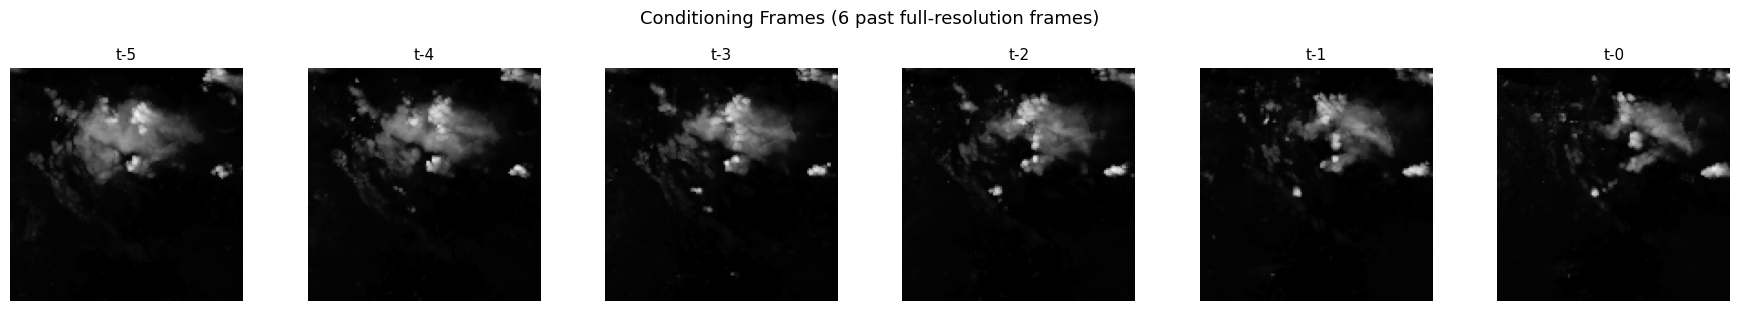

In [3]:
# Plot conditioning frames (past 6 frames)
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i in range(6):
    axes[i].imshow(condition[i], cmap="gray", vmin=0, vmax=1)
    axes[i].set_title(f"t-{5-i}", fontsize=11)
    axes[i].axis("off")
fig.suptitle("Conditioning Frames (6 past full-resolution frames)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

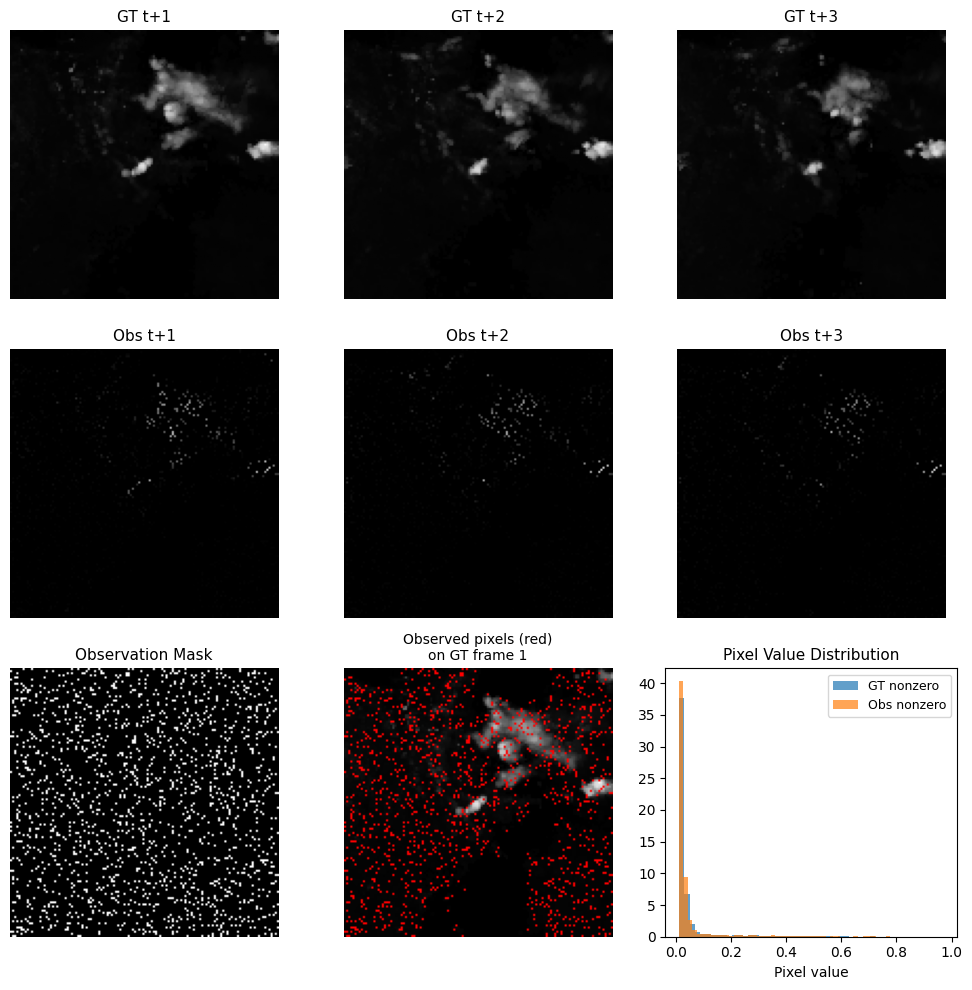

In [4]:
# Plot observation mask and sparse observations vs ground truth
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

# Row 0: Ground truth future frames
for j in range(3):
    axes[0, j].imshow(target[j], cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"GT t+{j+1}", fontsize=11)
    axes[0, j].axis("off")
axes[0, 0].set_ylabel("Ground Truth", fontsize=12, rotation=0, labelpad=80, va="center")

# Row 1: Sparse observations
for j in range(3):
    axes[1, j].imshow(observations[j], cmap="gray", vmin=0, vmax=1)
    axes[1, j].set_title(f"Obs t+{j+1}", fontsize=11)
    axes[1, j].axis("off")
axes[1, 0].set_ylabel("Observations\n(~10% pixels)", fontsize=12, rotation=0, labelpad=80, va="center")

# Row 2: Mask and difference
axes[2, 0].imshow(mask[0], cmap="gray", vmin=0, vmax=1)
axes[2, 0].set_title("Observation Mask", fontsize=11)
axes[2, 0].axis("off")

# Show where observations are nonzero overlaid on GT
overlay = np.zeros((128, 128, 3))
overlay[:, :, 0] = target[0]  # red channel = GT
overlay[:, :, 1] = target[0]  # green channel = GT
overlay[:, :, 2] = target[0]  # blue channel = GT
obs_locs = observations[0] > 0.01
overlay[obs_locs, 0] = 1.0  # mark observed pixels in red
overlay[obs_locs, 1] = 0.0
overlay[obs_locs, 2] = 0.0
axes[2, 1].imshow(np.clip(overlay, 0, 1))
axes[2, 1].set_title("Observed pixels (red)\non GT frame 1", fontsize=10)
axes[2, 1].axis("off")

axes[2, 2].hist(target[target > 0.01].flatten(), bins=50, alpha=0.7, label="GT nonzero", density=True)
axes[2, 2].hist(observations[observations > 0.01].flatten(), bins=50, alpha=0.7, label="Obs nonzero", density=True)
axes[2, 2].set_title("Pixel Value Distribution", fontsize=11)
axes[2, 2].legend(fontsize=9)
axes[2, 2].set_xlabel("Pixel value")

plt.tight_layout()
plt.show()

## 3. Forward Model Verification

We verify the forward model by applying the mask to the ground truth and comparing with the stored observations. The forward model is simply element-wise masking plus small Gaussian noise:

$$\mathbf{y} = \mathbf{M} \odot \mathbf{x} + \mathcal{N}(0, 0.001^2)$$

In [5]:
from src.physics_model import make_observation_operator, forward_model

# Apply mask to ground truth (noise-free)
operator = make_observation_operator(mask)
masked_gt = operator(target)

# Compare with stored observations (which include small noise)
residual = np.abs(observations - masked_gt)
print(f"Max residual between observations and masked GT: {residual.max():.6f}")
print(f"Mean residual: {residual.mean():.6f}")
print(f"(Expected ~sigma*coverage = {0.001 * mask.mean():.6f} for mean)")

# Verify mask coverage
print(f"\nMask coverage: {mask.mean():.4f} ({mask.sum():.0f} / {mask.size} pixels)")
print(f"Expected ~10% = {0.1 * mask[0].size:.0f} pixels")

Max residual between observations and masked GT: 0.004479
Mean residual: 0.000434
(Expected ~sigma*coverage = 0.000103 for mean)

Mask coverage: 0.1030 (1687 / 16384 pixels)
Expected ~10% = 1638 pixels


## 4. Load Reference Reconstruction

We load the precomputed FlowDAS reconstruction from `evaluation/reference_outputs/`. This was generated using the full inference pipeline: guided EM sampling with 500 steps, MC_times=25, and 3 autoregressive rollout steps.

To run the full reconstruction from scratch (requires GPU, ~30 min per sample):
```python
# from src.solvers import load_drift_model, StochasticInterpolant, autoregressive_reconstruct
# from src.preprocessing import scale_to_model, scale_from_model
# import torch
#
# device = "cuda"
# model = load_drift_model(os.path.join(TASK_DIR, "model", "latest.pt"), device=device)
# interpolant = StochasticInterpolant(beta_fn="t^2", sigma_coef=1.0)
# mask_tensor = torch.from_numpy(mask).float().to(device)
# operator = lambda x: x * mask_tensor
# noiser = lambda x: x + torch.randn_like(x) * 0.001
# cond_t = torch.from_numpy(scale_to_model(condition)).float().unsqueeze(0).to(device)
# obs_t = torch.from_numpy(scale_to_model(observations)).float().unsqueeze(0).to(device)
# with torch.no_grad():
#     recon_t = autoregressive_reconstruct(model, interpolant, cond_t, obs_t,
#                                          operator, noiser, n_steps=500, mc_times=25, auto_steps=3, device=device)
# recon = scale_from_model(recon_t[0].cpu().numpy())
```

In [6]:
# Load precomputed reference reconstruction
ref_data = np.load(os.path.join(REF_DIR, "reconstruction.npz"))
recon = ref_data["reconstructed_frames"][0]  # (3, 128, 128)

print(f"Reconstruction shape: {recon.shape}")
print(f"Reconstruction range: [{recon.min():.4f}, {recon.max():.4f}]")

Reconstruction shape: (3, 128, 128)
Reconstruction range: [-0.0686, 1.0113]


## 5. Results: Comparison

Side-by-side comparison of conditioning context, sparse observations, ground truth, and FlowDAS reconstruction.

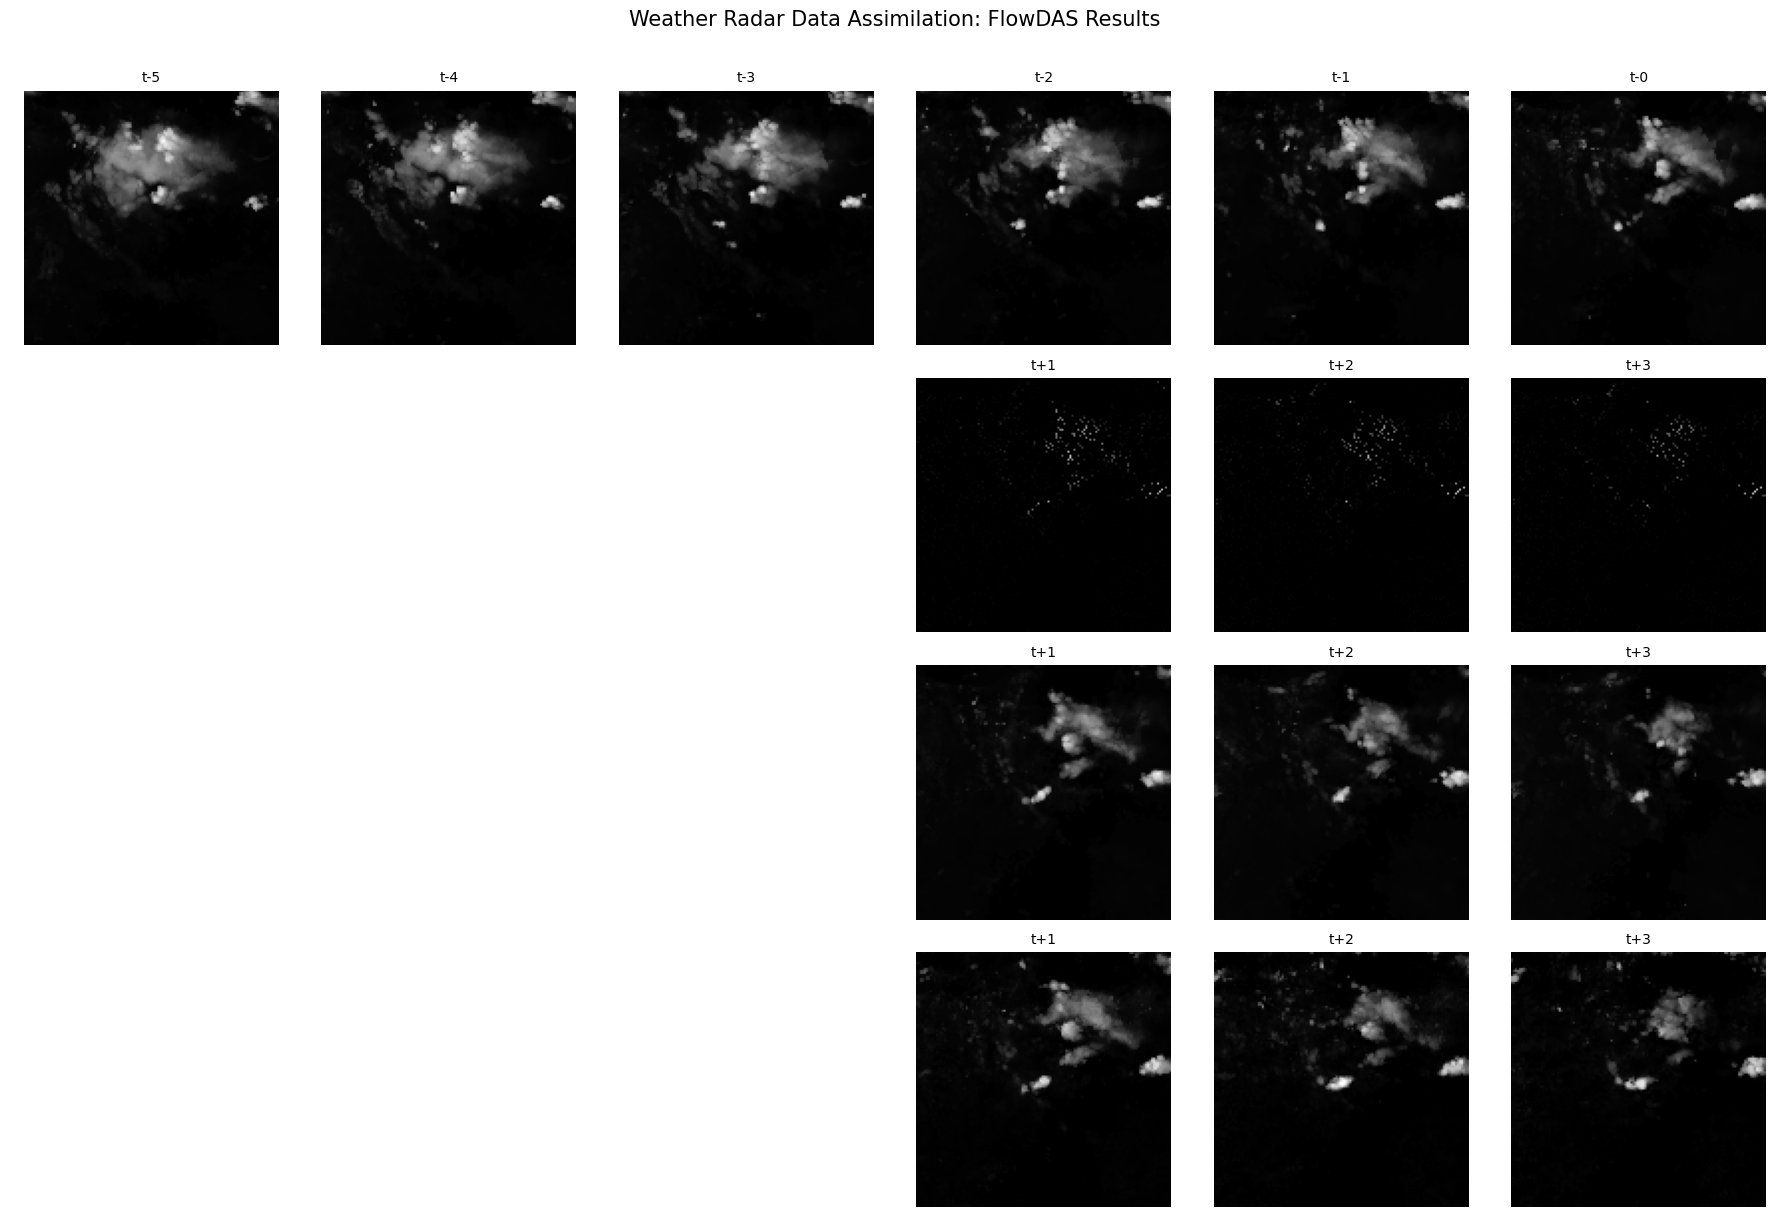

In [7]:
fig, axes = plt.subplots(4, 6, figsize=(18, 12))

# Turn off all axes
for ax_row in axes:
    for ax in ax_row:
        ax.axis("off")

# Row 0: Condition frames
for j in range(6):
    axes[0, j].imshow(condition[j], cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"t-{5-j}", fontsize=10)
axes[0, 0].set_ylabel("Condition", fontsize=13, rotation=0, labelpad=70, va="center")

# Row 1: Sparse observations (centered in last 3 cols)
for j in range(3):
    axes[1, j+3].imshow(observations[j], cmap="gray", vmin=0, vmax=1)
    axes[1, j+3].set_title(f"t+{j+1}", fontsize=10)
axes[1, 0].set_ylabel("Observation\n(~10%)", fontsize=13, rotation=0, labelpad=70, va="center")

# Row 2: Ground truth
for j in range(3):
    axes[2, j+3].imshow(target[j], cmap="gray", vmin=0, vmax=1)
    axes[2, j+3].set_title(f"t+{j+1}", fontsize=10)
axes[2, 0].set_ylabel("Ground Truth", fontsize=13, rotation=0, labelpad=70, va="center")

# Row 3: Reconstruction
for j in range(3):
    axes[3, j+3].imshow(np.clip(recon[j], 0, 1), cmap="gray", vmin=0, vmax=1)
    axes[3, j+3].set_title(f"t+{j+1}", fontsize=10)
axes[3, 0].set_ylabel("FlowDAS\nReconstruction", fontsize=13, rotation=0, labelpad=70, va="center")

plt.suptitle("Weather Radar Data Assimilation: FlowDAS Results", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 6. Error Analysis

Per-frame absolute error maps and quantitative metrics (NCC and NRMSE).

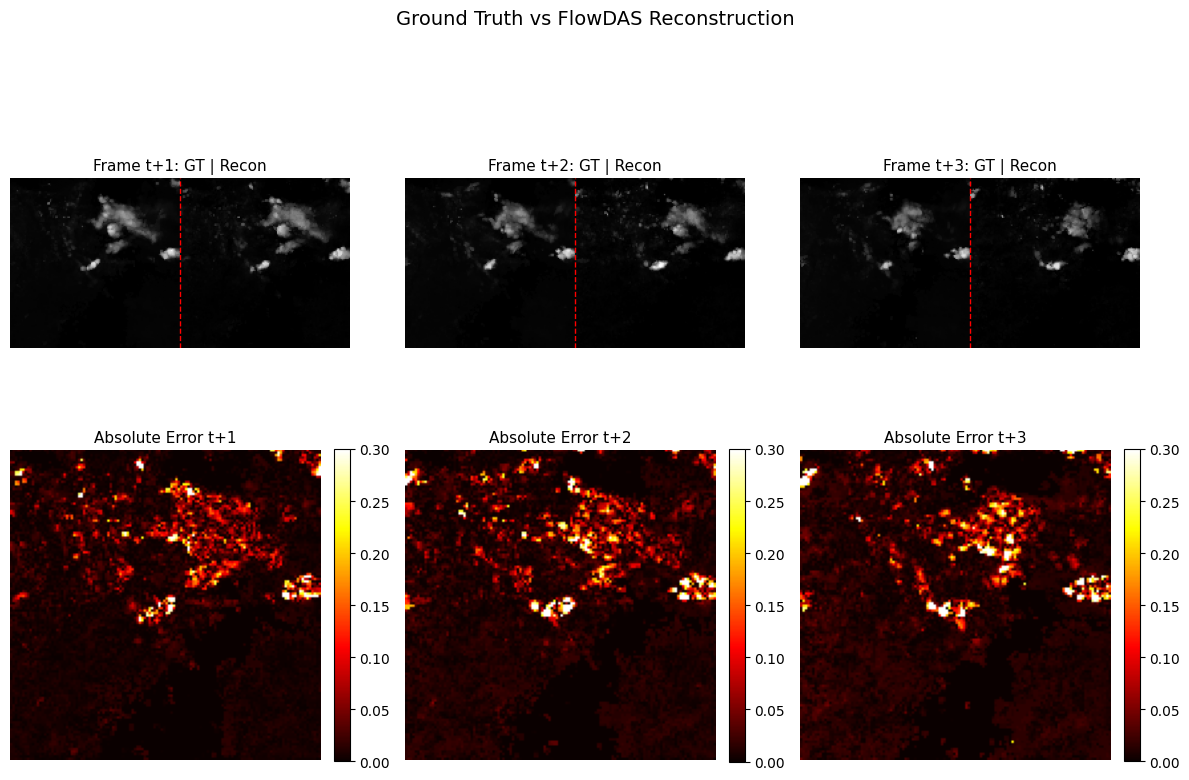

In [8]:
# Per-frame error maps
recon_clipped = np.clip(recon, 0, 1)
error = np.abs(target - recon_clipped)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for j in range(3):
    # Row 0: GT vs Recon side by side
    combined = np.concatenate([target[j], recon_clipped[j]], axis=1)
    axes[0, j].imshow(combined, cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"Frame t+{j+1}: GT | Recon", fontsize=11)
    axes[0, j].axvline(x=127.5, color="red", linewidth=1, linestyle="--")
    axes[0, j].axis("off")

    # Row 1: Error map
    im = axes[1, j].imshow(error[j], cmap="hot", vmin=0, vmax=0.3)
    axes[1, j].set_title(f"Absolute Error t+{j+1}", fontsize=11)
    axes[1, j].axis("off")
    plt.colorbar(im, ax=axes[1, j], fraction=0.046, pad=0.04)

plt.suptitle("Ground Truth vs FlowDAS Reconstruction", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
def ncc(x, ref):
    """Cosine similarity (no mean subtraction)."""
    x_flat = x.flatten()
    r_flat = ref.flatten()
    return float(np.dot(x_flat, r_flat) / (np.linalg.norm(x_flat) * np.linalg.norm(r_flat)))

def nrmse(x, ref):
    """NRMSE normalised by dynamic range."""
    rms = np.sqrt(np.mean((x - ref) ** 2))
    return float(rms / (ref.max() - ref.min()))

# Overall metrics
overall_ncc = ncc(recon, target)
overall_nrmse = nrmse(recon, target)

print("=" * 55)
print(f"{'Metric':<20} {'Overall':>10} {'Frame 1':>8} {'Frame 2':>8} {'Frame 3':>8}")
print("=" * 55)

frame_nccs = [ncc(recon[i], target[i]) for i in range(3)]
frame_nrmses = [nrmse(recon[i], target[i]) for i in range(3)]

print(f"{'NCC':<20} {overall_ncc:>10.4f} {frame_nccs[0]:>8.4f} {frame_nccs[1]:>8.4f} {frame_nccs[2]:>8.4f}")
print(f"{'NRMSE':<20} {overall_nrmse:>10.4f} {frame_nrmses[0]:>8.4f} {frame_nrmses[1]:>8.4f} {frame_nrmses[2]:>8.4f}")
print("=" * 55)

# Load evaluation boundaries
with open(os.path.join(TASK_DIR, "evaluation", "metrics.json")) as f:
    metrics = json.load(f)

print(f"\nEvaluation boundaries:")
print(f"  NCC  >= {metrics['ncc_boundary']:.4f} (90% of baseline)")
print(f"  NRMSE <= {metrics['nrmse_boundary']:.4f} (110% of baseline)")
print(f"\nFlowDAS passes: NCC={overall_ncc:.4f} >= {metrics['ncc_boundary']:.4f} -> {'PASS' if overall_ncc >= metrics['ncc_boundary'] else 'FAIL'}")
print(f"                 NRMSE={overall_nrmse:.4f} <= {metrics['nrmse_boundary']:.4f} -> {'PASS' if overall_nrmse <= metrics['nrmse_boundary'] else 'FAIL'}")

Metric                  Overall  Frame 1  Frame 2  Frame 3
NCC                      0.8706   0.9212   0.8563   0.8134
NRMSE                    0.0514   0.0441   0.0571   0.0610

Evaluation boundaries:
  NCC  >= 0.7835 (90% of baseline)
  NRMSE <= 0.0565 (110% of baseline)

FlowDAS passes: NCC=0.8706 >= 0.7835 -> PASS
                 NRMSE=0.0514 <= 0.0565 -> PASS


## 7. Per-Frame Quality Degradation

The autoregressive structure means later frames are harder to reconstruct, since each prediction conditions on the previous one (error accumulation). We visualize NCC and NRMSE across the 3 prediction frames.

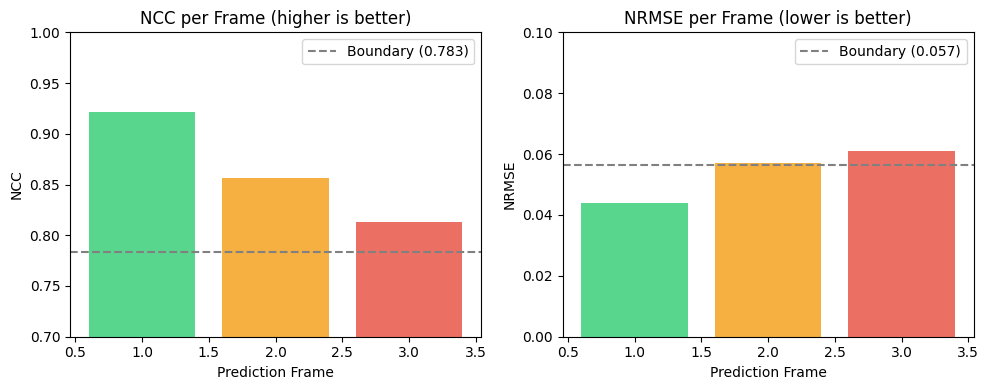

Observation: NCC decreases and NRMSE increases for later frames,
consistent with error accumulation in autoregressive rollout.


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

frames = [1, 2, 3]
ax1.bar(frames, frame_nccs, color=["#2ecc71", "#f39c12", "#e74c3c"], alpha=0.8)
ax1.set_xlabel("Prediction Frame")
ax1.set_ylabel("NCC")
ax1.set_title("NCC per Frame (higher is better)")
ax1.set_ylim(0.7, 1.0)
ax1.axhline(y=metrics["ncc_boundary"], color="gray", linestyle="--", label=f"Boundary ({metrics['ncc_boundary']:.3f})")
ax1.legend()

ax2.bar(frames, frame_nrmses, color=["#2ecc71", "#f39c12", "#e74c3c"], alpha=0.8)
ax2.set_xlabel("Prediction Frame")
ax2.set_ylabel("NRMSE")
ax2.set_title("NRMSE per Frame (lower is better)")
ax2.set_ylim(0, 0.1)
ax2.axhline(y=metrics["nrmse_boundary"], color="gray", linestyle="--", label=f"Boundary ({metrics['nrmse_boundary']:.3f})")
ax2.legend()

plt.tight_layout()
plt.show()

print("Observation: NCC decreases and NRMSE increases for later frames,")
print("consistent with error accumulation in autoregressive rollout.")

## 8. Conclusion

FlowDAS achieves strong reconstruction quality (NCC=0.87, NRMSE=0.051) from only ~10% observed pixels by combining:

1. **Learned generative prior**: A UNet drift model trained on weather radar sequences captures the joint distribution of past-and-future frames.
2. **Gradient-based guidance**: At each EM sampling step, the observation likelihood gradient steers samples toward data consistency.
3. **Monte Carlo variance reduction**: 25 forward estimates per step reduce gradient noise.
4. **Autoregressive conditioning**: Each predicted frame updates the conditioning window for the next prediction.

The quality degrades gracefully across prediction steps (NCC: 0.92 -> 0.86 -> 0.81), demonstrating the challenge of multi-step autoregressive prediction with sparse observations.